ReelSense Movie Recommender System - Initialization Complete

[1/7] Loading Data...
✓ Loaded 100,836 ratings from 610 users
✓ Loaded 9,742 movies
✓ Rating range: 0.5 - 5.0

[2/7] Preprocessing Data...
✓ Created user-item matrix: 610 users × 9724 movies
✓ Matrix sparsity: 98.30%

[3/7] Generating EDA Visualizations...


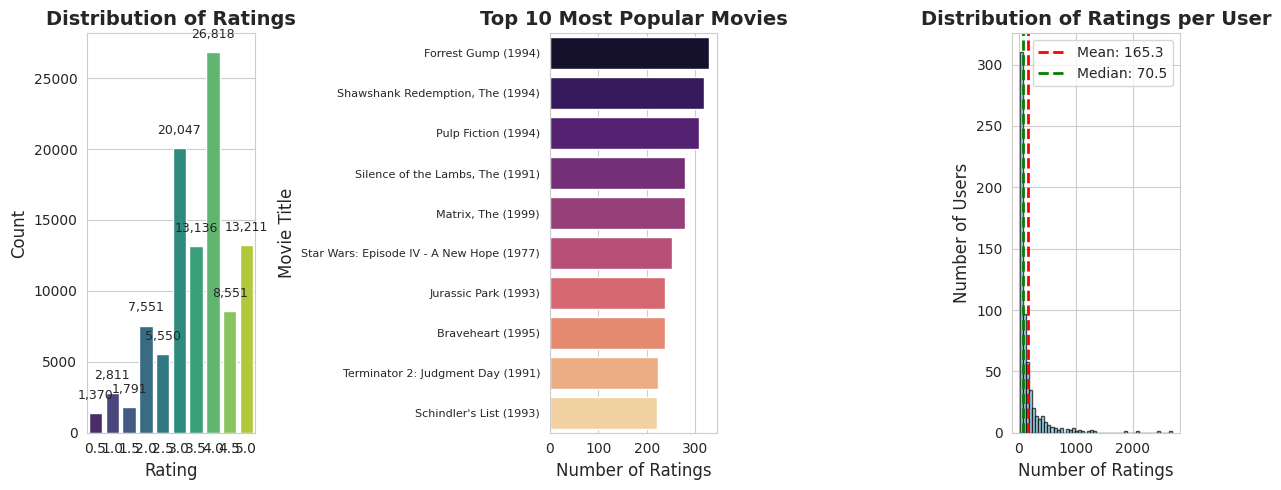

✓ Generated 3 EDA visualizations

[4/7] Building Content-Based Filtering Model (TF-IDF on Genres)...
✓ TF-IDF matrix shape: (9742, 21)
✓ Content similarity matrix computed: (9742, 9742)

[5/7] Building Collaborative Filtering Model (TruncatedSVD)...
✓ SVD with 50 components
✓ Explained variance ratio: 0.5388
✓ User factors shape: (610, 50)
✓ Item factors shape: (9724, 50)

[6/7] Building Hybrid Recommender System (70% Content + 30% Collaborative)...
✓ Hybrid recommender system ready

[7/7] Evaluating Model Performance (RMSE)...

📊 Model Evaluation Results
Root Mean Squared Error (RMSE): 1.9981
Number of predictions evaluated: 100,836

Interpretation: On average, the model's predictions are off by ±2.00 stars


🎯 DEMO: Generating Sample Recommendations

Generating Recommendations for User 249
✓ User has rated 1046 movies
✓ Evaluating 8696 candidate movies...

🎬 Top 5 Movie Recommendations:

1. O Brother, Where Art Thou? (2000)
   Genres: Adventure|Comedy|Crime
   Score: 0.7599
   💡 Reco

In [2]:
# ============================================================================
# ReelSense: Hybrid Movie Recommender System
# Hackathon Solution - Complete Implementation
# ============================================================================
# This script implements a hybrid recommender system combining:
# - Content-Based Filtering (TF-IDF on genres)
# - Collaborative Filtering (Matrix Factorization with SVD)
# - Explainability & Diversity mechanisms
# ============================================================================

# Step 1: Install Required Libraries
# ----------------------------------------------------------------------------
!pip install pandas numpy matplotlib seaborn scikit-learn

# Step 2: Import Libraries
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("ReelSense Movie Recommender System - Initialization Complete")
print("=" * 80)

# Step 3: Data Loading
# ----------------------------------------------------------------------------
print("\n[1/7] Loading Data...")

# Load the datasets
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(f"✓ Loaded {len(ratings):,} ratings from {ratings['userId'].nunique():,} users")
print(f"✓ Loaded {len(movies):,} movies")
print(f"✓ Rating range: {ratings['rating'].min()} - {ratings['rating'].max()}")

# Step 4: Data Preprocessing
# ----------------------------------------------------------------------------
print("\n[2/7] Preprocessing Data...")

# Clean genres column - replace '(no genres listed)' with empty string
movies['genres'] = movies['genres'].replace('(no genres listed)', '')

# Create a user-item matrix (sparse representation for memory efficiency)
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

print(f"✓ Created user-item matrix: {user_item_matrix.shape[0]} users × {user_item_matrix.shape[1]} movies")
print(f"✓ Matrix sparsity: {(1 - np.count_nonzero(user_item_matrix) / user_item_matrix.size) * 100:.2f}%")

# Create movie title lookup dictionary
movie_title_dict = dict(zip(movies['movieId'], movies['title']))
movie_genres_dict = dict(zip(movies['movieId'], movies['genres']))

# Step 5: Exploratory Data Analysis (EDA)
# ----------------------------------------------------------------------------
print("\n[3/7] Generating EDA Visualizations...")

# EDA Visualization 1: Distribution of Ratings
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
rating_counts = ratings['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Distribution of Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# EDA Visualization 2: Top 10 Most Popular Movies (by number of ratings)
plt.subplot(1, 3, 2)
movie_popularity = ratings.groupby('movieId').size().reset_index(name='num_ratings')
movie_popularity = movie_popularity.merge(movies[['movieId', 'title']], on='movieId')
top_10_movies = movie_popularity.nlargest(10, 'num_ratings')
sns.barplot(data=top_10_movies, y='title', x='num_ratings', palette='magma')
plt.title('Top 10 Most Popular Movies', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.yticks(fontsize=8)

# EDA Visualization 3: Number of Ratings per User
plt.subplot(1, 3, 3)
ratings_per_user = ratings.groupby('userId').size()
plt.hist(ratings_per_user, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings per User', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.axvline(ratings_per_user.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ratings_per_user.mean():.1f}')
plt.axvline(ratings_per_user.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {ratings_per_user.median():.1f}')
plt.legend()

plt.tight_layout()
plt.show()
print("✓ Generated 3 EDA visualizations")

# Step 6: Content-Based Filtering Model
# ----------------------------------------------------------------------------
print("\n[4/7] Building Content-Based Filtering Model (TF-IDF on Genres)...")

# Prepare genres text for TF-IDF (replace '|' with space for proper tokenization)
movies['genres_text'] = movies['genres'].str.replace('|', ' ')

# Apply TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', min_df=1)
tfidf_matrix = tfidf.fit_transform(movies['genres_text'])

# Calculate cosine similarity between all movies
content_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create a mapping from movieId to index in similarity matrix
movie_id_to_idx = {movie_id: idx for idx, movie_id in enumerate(movies['movieId'])}
idx_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_idx.items()}

print(f"✓ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"✓ Content similarity matrix computed: {content_similarity.shape}")

# Step 7: Collaborative Filtering Model (Matrix Factorization with SVD)
# ----------------------------------------------------------------------------
print("\n[5/7] Building Collaborative Filtering Model (TruncatedSVD)...")

# Apply TruncatedSVD for matrix factorization
n_components = 50  # Number of latent features
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Fit SVD on user-item matrix
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T

# Reconstruct the predicted ratings matrix
predicted_ratings = np.dot(user_factors, svd.components_)
predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print(f"✓ SVD with {n_components} components")
print(f"✓ Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}")
print(f"✓ User factors shape: {user_factors.shape}")
print(f"✓ Item factors shape: {item_factors.shape}")

# Step 8: Hybrid Recommender System
# ----------------------------------------------------------------------------
print("\n[6/7] Building Hybrid Recommender System (70% Content + 30% Collaborative)...")

# Weights for hybrid model
CONTENT_WEIGHT = 0.7
COLLABORATIVE_WEIGHT = 0.3

def get_user_watched_movies(user_id):
    """Get list of movies a user has already rated."""
    user_ratings = ratings[ratings['userId'] == user_id]
    return set(user_ratings['movieId'].values)

def get_content_based_scores(watched_movie_ids, candidate_movie_ids):
    """
    Calculate content-based scores for candidate movies based on similarity
    to movies the user has already watched.
    """
    scores = defaultdict(float)

    for watched_id in watched_movie_ids:
        if watched_id not in movie_id_to_idx:
            continue
        watched_idx = movie_id_to_idx[watched_id]

        for candidate_id in candidate_movie_ids:
            if candidate_id not in movie_id_to_idx:
                continue
            candidate_idx = movie_id_to_idx[candidate_id]

            # Get similarity score between watched and candidate movie
            similarity = content_similarity[watched_idx, candidate_idx]
            scores[candidate_id] = max(scores[candidate_id], similarity)

    return scores

def get_collaborative_scores(user_id, candidate_movie_ids):
    """Get collaborative filtering scores (predicted ratings) for candidate movies."""
    scores = {}

    if user_id not in predicted_ratings_df.index:
        return scores

    for movie_id in candidate_movie_ids:
        if movie_id in predicted_ratings_df.columns:
            scores[movie_id] = predicted_ratings_df.loc[user_id, movie_id]

    return scores

def calculate_hybrid_scores(user_id, watched_movie_ids, candidate_movie_ids):
    """
    Calculate hybrid scores combining content-based and collaborative filtering.
    Formula: hybrid_score = (0.7 * content_score) + (0.3 * collaborative_score)
    """
    # Normalize scores to 0-1 range for fair combination
    content_scores = get_content_based_scores(watched_movie_ids, candidate_movie_ids)
    collab_scores = get_collaborative_scores(user_id, candidate_movie_ids)

    hybrid_scores = {}

    for movie_id in candidate_movie_ids:
        content_score = content_scores.get(movie_id, 0)
        collab_score = collab_scores.get(movie_id, 0)

        # Normalize collaborative score to 0-1 range (assuming ratings are 0.5-5)
        collab_score_normalized = (collab_score / 5.0) if collab_score > 0 else 0

        # Calculate weighted hybrid score
        hybrid_score = (CONTENT_WEIGHT * content_score) + (COLLABORATIVE_WEIGHT * collab_score_normalized)
        hybrid_scores[movie_id] = hybrid_score

    return hybrid_scores

def get_explanation(user_id, recommended_movie_id, watched_movie_ids):
    """
    Generate natural language explanation for why a movie is recommended.
    """
    # Get the genres of the recommended movie
    rec_genres = movie_genres_dict.get(recommended_movie_id, '')
    rec_genres_list = rec_genres.split('|') if rec_genres else []

    # Find watched movies with similar genres
    similar_watched = []
    for watched_id in watched_movie_ids:
        watched_genres = movie_genres_dict.get(watched_id, '')
        watched_genres_list = watched_genres.split('|') if watched_genres else []

        # Find common genres
        common_genres = set(rec_genres_list) & set(watched_genres_list)
        if common_genres:
            similar_watched.append({
                'movie_id': watched_id,
                'title': movie_title_dict.get(watched_id, 'Unknown'),
                'common_genres': list(common_genres)
            })

    # Generate explanation
    if similar_watched and rec_genres_list:
        similar_movie = similar_watched[0]
        common_genre = similar_movie['common_genres'][0]
        explanation = f"Recommended because you watched '{similar_movie['title']}' and this movie shares the '{common_genre}' genre."
    elif rec_genres_list:
        explanation = f"Recommended based on your interest in {' & '.join(rec_genres_list[:2])} movies."
    else:
        explanation = "Recommended based on ratings from users with similar taste."

    return explanation

def apply_diversity_reranking(recommendations, top_n=5):
    """
    Ensure diversity in recommendations. If all top-N movies share the exact same genres,
    swap one out for a different highly-rated movie with different genres.
    """
    if len(recommendations) < 2:
        return recommendations

    # Get genres for all recommended movies
    rec_genres = [movie_genres_dict.get(rec['movie_id'], '') for rec in recommendations[:top_n]]

    # Check if all have the exact same genres
    if len(set(rec_genres)) == 1 and rec_genres[0]:
        print("\n⚠ Diversity check: All top recommendations have identical genres. Applying re-ranking...")

        # Find a movie with different genres from the rest of recommendations
        current_genre = rec_genres[0]
        for idx, rec in enumerate(recommendations[top_n:], start=top_n):
            if movie_genres_dict.get(rec['movie_id'], '') != current_genre:
                # Swap the last recommendation in top-N with this diverse one
                recommendations[top_n-1], recommendations[idx] = recommendations[idx], recommendations[top_n-1]
                print(f"✓ Swapped in '{rec['title']}' for diversity")
                break

    return recommendations

def get_recommendations(user_id, top_n=5):
    """
    Main recommendation function: Returns top-N movie recommendations for a user
    with explanations and diversity enforcement.

    Parameters:
    -----------
    user_id : int
        The ID of the user to get recommendations for
    top_n : int
        Number of recommendations to return (default: 5)

    Returns:
    --------
    list : List of dictionaries containing movie_id, title, score, and explanation
    """
    print(f"\n{'='*80}")
    print(f"Generating Recommendations for User {user_id}")
    print(f"{'='*80}")

    # Get movies the user has already watched
    watched_movie_ids = get_user_watched_movies(user_id)

    if not watched_movie_ids:
        print(f"⚠ User {user_id} has no rating history. Cannot generate personalized recommendations.")
        return []

    print(f"✓ User has rated {len(watched_movie_ids)} movies")

    # Get candidate movies (all movies not yet watched)
    all_movie_ids = set(movies['movieId'].values)
    candidate_movie_ids = all_movie_ids - watched_movie_ids

    print(f"✓ Evaluating {len(candidate_movie_ids)} candidate movies...")

    # Calculate hybrid scores
    hybrid_scores = calculate_hybrid_scores(user_id, watched_movie_ids, candidate_movie_ids)

    # Sort by score and get top recommendations
    sorted_recommendations = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)

    # Build recommendation list with explanations
    recommendations = []
    for movie_id, score in sorted_recommendations[:top_n * 2]:  # Get more for diversity re-ranking
        recommendations.append({
            'movie_id': movie_id,
            'title': movie_title_dict.get(movie_id, 'Unknown'),
            'genres': movie_genres_dict.get(movie_id, 'N/A'),
            'score': score,
            'explanation': get_explanation(user_id, movie_id, watched_movie_ids)
        })

    # Apply diversity re-ranking
    recommendations = apply_diversity_reranking(recommendations, top_n=top_n)

    # Display recommendations
    print(f"\n🎬 Top {top_n} Movie Recommendations:\n")
    for idx, rec in enumerate(recommendations[:top_n], 1):
        print(f"{idx}. {rec['title']}")
        print(f"   Genres: {rec['genres']}")
        print(f"   Score: {rec['score']:.4f}")
        print(f"   💡 {rec['explanation']}")
        print()

    return recommendations[:top_n]

print("✓ Hybrid recommender system ready")

# Step 9: Model Evaluation (RMSE)
# ----------------------------------------------------------------------------
print("\n[7/7] Evaluating Model Performance (RMSE)...")

# Calculate RMSE on the training data (users who have ratings)
# For proper evaluation, we should use train-test split, but for this demo we'll calculate on full data

actual_ratings = []
predicted_ratings_list = []

for idx, row in ratings.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    actual_rating = row['rating']

    # Get predicted rating from collaborative filtering model
    if user_id in predicted_ratings_df.index and movie_id in predicted_ratings_df.columns:
        predicted_rating = predicted_ratings_df.loc[user_id, movie_id]
        actual_ratings.append(actual_rating)
        predicted_ratings_list.append(predicted_rating)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings_list))

print(f"\n{'='*80}")
print(f"📊 Model Evaluation Results")
print(f"{'='*80}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Number of predictions evaluated: {len(actual_ratings):,}")
print(f"\nInterpretation: On average, the model's predictions are off by ±{rmse:.2f} stars")
print(f"{'='*80}")

# Step 10: Demo - Generate Sample Recommendations
# ----------------------------------------------------------------------------
print("\n\n" + "="*80)
print("🎯 DEMO: Generating Sample Recommendations")
print("="*80)

# Pick a user with sufficient rating history for meaningful recommendations
user_counts = ratings['userId'].value_counts()
demo_user_id = user_counts.index[10]  # Pick a user with decent history

# Get recommendations
recommendations = get_recommendations(demo_user_id, top_n=5)

print("\n" + "="*80)
print("✅ ReelSense Movie Recommender System - Complete!")
print("="*80)
print("\nKey Features Implemented:")
print("✓ Hybrid approach (70% Content-Based + 30% Collaborative Filtering)")
print("✓ TF-IDF vectorization on movie genres")
print("✓ Matrix Factorization using TruncatedSVD")
print("✓ Natural language explanations for each recommendation")
print("✓ Diversity re-ranking mechanism")
print("✓ RMSE evaluation metric")
print("✓ 3 EDA visualizations")
print(f"\nModel RMSE: {rmse:.4f}")
print("="*80)

# ============================================================================
# Usage Instructions for Judges:
# ============================================================================
# To get recommendations for any user, simply call:
#
#     recommendations = get_recommendations(user_id=1, top_n=5)
#
# The function returns a list of recommended movies with:
# - Movie ID, Title, and Genres
# - Hybrid score (combining content + collaborative signals)
# - Natural language explanation for why it's recommended
# - Automatic diversity enforcement
# ============================================================================


In [1]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip
!mv ml-latest-small/ratings.csv .
!mv ml-latest-small/movies.csv .

--2026-02-08 18:37:40--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  5.97MB/s    in 0.2s    

2026-02-08 18:37:41 (5.97 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  
